In [1]:
import torch
from torch import nn
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
train_dataset = ImageFolder(root = '/content/drive/MyDrive/landmark_classification/data/landmark_top51/train')

In [5]:
num_classes = len(train_dataset.classes)
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Number of classes:", num_classes)
print("Some classes:", list(idx_to_class.values())[:5])

Number of classes: 51
Some classes: ['%C3%87ufut_Qale', "Akbar's_Tomb", 'Akkerman_fortress', 'Catedral_San_Sebasti%C3%A1n,_Cochabamba', 'Corktown,_Toronto']


In [6]:

def load_checkpoint_convnext(filepath, device, num_classes=51):
    # Load checkpoint
    checkpoint = torch.load(filepath, map_location=device)

    # Rebuild the ConvNeXt model
    model = models.convnext_small(weights=None)  # no pretrained weights

    # Replace the classifier for your number of classes
    num_ftrs = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(num_ftrs, num_classes)

    # Load the trained weights
    model.load_state_dict(checkpoint['model_state'])

    # Move to device
    model = model.to(device)
    model.eval()

    return model, checkpoint  # return checkpoint if you want optimizer, scheduler, etc.

In [7]:
def preprocess_image(image_path):
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    try:
        image = Image.open(image_path).convert("RGB")
        input_tensor = preprocess(image).unsqueeze(0).to(device)  # add batch dim and move to device
        return input_tensor, image
    except Exception as e:
        print(f"Warning: Could not process image {image_path}: {e}")
        return None, None

In [8]:
def predict_topk(model, image_path, topk=5):
    input_tensor, orig_image = preprocess_image(image_path)
    if input_tensor is None or orig_image is None:
        return None, None, None

    with torch.no_grad():
        outputs = model(input_tensor)
        ps = torch.nn.functional.softmax(outputs, dim=1)
        top_p, top_idx = ps.topk(topk, dim=1)

    top_p = top_p.cpu().numpy().squeeze()
    top_idx = top_idx.cpu().numpy().squeeze()

    # Convert indices to class names
    top_classes = [idx_to_class[i] for i in top_idx]

    return top_p, top_classes, orig_image

In [9]:
def show_prediction_with_bar(image, top_p, top_classes):
    plt.figure(figsize=(8,6))

    # Show image
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Prediction: {top_classes[0]}")

    # Bar chart
    plt.subplot(1,2,2)
    y_pos = np.arange(len(top_classes))
    plt.barh(y_pos, top_p[::-1], color='skyblue')
    plt.yticks(y_pos, top_classes[::-1])
    plt.xlabel("Probability")
    plt.title("Top-5 Predictions")

    plt.tight_layout()
    plt.show()

Prediction: Matka_Canyon (Confidence: 0.999)


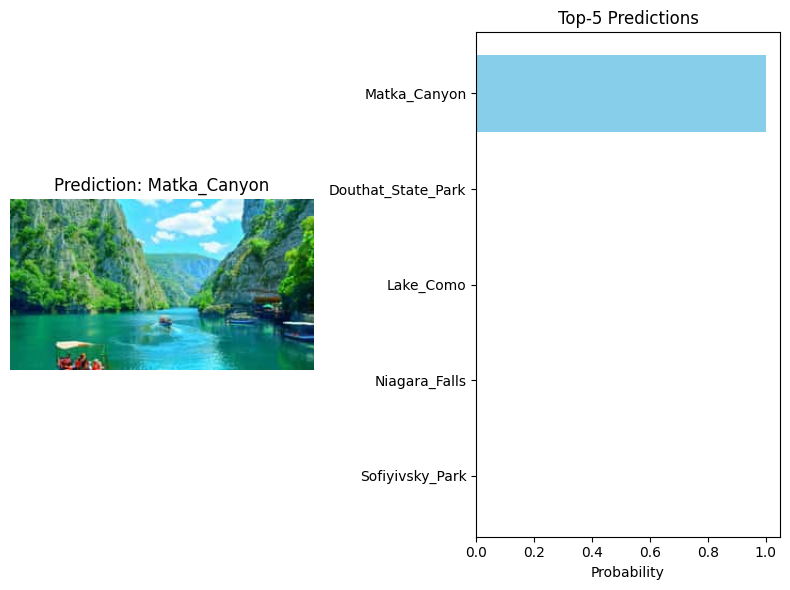

In [10]:
checkpoint_path = "/content/drive/MyDrive/landmark_classification/new_checkpoints/checkpoint_finetune_epoch_6.pth"  # update to your checkpoint
model, _ = load_checkpoint_convnext(checkpoint_path, device, num_classes)
CONF_THRESHOLD = 0.5

# ******************************
# Example: Single image prediction
# ******************************
img_path = "/content/drive/MyDrive/landmark_classification/download1.jpeg"  # update to your test image
top_p, top_classes, orig_image = predict_topk(model, img_path, topk=5)

predicted_label = (
    top_classes[0]
    if top_p[0] >= CONF_THRESHOLD
    else "Unknown"
)
print(f"Prediction: {predicted_label} (Confidence: {top_p[0]:.3f})")
show_prediction_with_bar(orig_image, top_p, top_classes)

In [11]:
from collections import Counter

test_folder = "/content/drive/MyDrive/landmark_classification/data/landmark_top51/test"
top5_counter = Counter()

for root, _, files in os.walk(test_folder):
    for file in files:
        if file.lower().endswith(('.jpg', '.png')):
            img_path = os.path.join(root, file)
            top_p, top_classes, _ = predict_topk(model, img_path, topk=5)
            if top_classes is not None:
                top5_counter.update(top_classes)  # count top-5 predictions

# ******************************
# Print the top 5 most frequent categories
# ******************************
print("Top 5 most frequently predicted categories in test set:")
for cls, count in top5_counter.most_common(5):
    print(f"{cls}: {count} times")

Top 5 most frequently predicted categories in test set:
Khotyn_Fortress: 1998 times
Pe%C5%A1ter: 1616 times
%C3%87ufut_Qale: 1538 times
Akkerman_fortress: 1532 times
Lviv: 1494 times
